In [ ]:
# Install the notebook's Python dependencies (safe to re-run; needed on a fresh kernel / Colab).
%pip install -q requests numpy matplotlib pyproj pillow


# MobilityAPI — Tutorial (request–response)

This notebook walks through the [OGC API – Moving Features](https://docs.ogc.org/is/22-003r3/22-003r3.html)
(Part 1 — Core) endpoints exposed by **MobilityAPI**, the thin compiled (Go) tier
over **MobilityDB**, using one day of AIS (Automatic Identification System) data
from the [Danish Maritime Authority](http://aisdata.ais.dk/).

Each moving-feature quantity is retrieved with a `GET`; its streaming counterpart,
[`tutorial-stream/tutorial.ipynb`](../tutorial-stream/tutorial.ipynb), delivers the
same quantities as Server-Sent Events from continuous queries.

## Relationship to the streaming tutorial

This notebook has a streaming counterpart,
[`tutorial-stream/tutorial.ipynb`](../tutorial-stream/tutorial.ipynb),
over the same `ships` collection. Both expose the same moving-feature quantities —
a feature, its speed-over-ground property, derived measures, and a windowed
aggregate — and differ only in interaction model: this notebook retrieves each
value with a `GET`, whereas the streaming tutorial registers a continuous query
and receives the values over Server-Sent Events.

| Quantity | Request–response | Streaming |
|---|---|---|
| A moving feature | `GET …/items/{id}` | the same vessel |
| Speed over ground | `GET …/tproperties/speed` | `POST …/queries` → SSE |
| Derived speed | `GET …/velocity` | a `transform` continuous query |
| Windowed aggregate | aggregate the returned series | a windowed continuous query |
| Visualization | a static plot | the live animated map |

## Setup

In [1]:
%matplotlib inline
import json, math, os, io, urllib.request
from datetime import datetime

import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from pyproj import Transformer
from PIL import Image

HOST = os.environ.get("MFAPI_HOST", "http://localhost:8088")  # the Go MobilityAPI tier (override with MFAPI_HOST)
COLLECTION_ID = os.environ.get("MFAPI_COLLECTION", "ships")

# the ships collection stores coordinates in EPSG:25832 (ETRS89 / UTM 32N, metres)
_to3857 = Transformer.from_crs(25832, 3857, always_xy=True)

Two small helpers — a self-contained XYZ-tile basemap (so we need only
`matplotlib` / `pyproj` / `Pillow`, not geopandas/contextily) and a trajectory
plotter that reads either the GeoJSON `geometry` or the MF-JSON `temporalGeometry`
of a feature.

In [2]:
# --- OSM XYZ-tile basemap (fetch + stitch), reprojecting data to Web Mercator ---
_WORLD = 20037508.342789244
_CACHE = "/tmp/mfapi_tiles"; os.makedirs(_CACHE, exist_ok=True)
def _tile(z, x, y):
    p = f"{_CACHE}/{z}_{x}_{y}.png"
    if not os.path.exists(p):
        req = urllib.request.Request(f"https://tile.openstreetmap.org/{z}/{x}/{y}.png",
                                     headers={"User-Agent": "mobilityapi-tutorial/1.0"})
        open(p, "wb").write(urllib.request.urlopen(req, timeout=25).read())
    return Image.open(p).convert("RGB")
def _m2t(x, y, z): n = 2**z; return (x+_WORLD)/(2*_WORLD)*n, (_WORLD-y)/(2*_WORLD)*n
def _t2m(tx, ty, z): n = 2**z; return tx/n*2*_WORLD-_WORLD, _WORLD-ty/n*2*_WORLD
def add_basemap(ax, xmin, ymin, xmax, ymax):
    span = max(xmax-xmin, ymax-ymin); z = 12
    for zz in range(3, 17):
        if span/(2*_WORLD/2**zz) >= 4: z = zz; break
    tx0, ty1 = _m2t(xmin, ymin, z); tx1, ty0 = _m2t(xmax, ymax, z)
    x0, x1 = math.floor(tx0), math.ceil(tx1); y0, y1 = math.floor(ty0), math.ceil(ty1)
    mos = Image.new("RGB", ((x1-x0)*256, (y1-y0)*256), (238, 238, 238))
    for xi in range(x0, x1):
        for yi in range(y0, y1):
            try: mos.paste(_tile(z, xi, yi), ((xi-x0)*256, (yi-y0)*256))
            except Exception: pass
    mx0, my1 = _t2m(x0, y0, z); mx1, my0 = _t2m(x1, y1, z)
    ax.imshow(mos, extent=[mx0, mx1, my0, my1], zorder=0)
    ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)

def feature_polylines(feat):
    """[x, y] polylines in EPSG:25832 from a feature's geometry or temporalGeometry."""
    out = []
    g = feat.get("geometry")
    if g and g.get("type") == "LineString": out.append(g["coordinates"])
    elif g and g.get("type") == "MultiLineString": out += g["coordinates"]
    tg = feat.get("temporalGeometry")
    if isinstance(tg, dict):
        for seq in tg.get("sequences", []): out.append(seq.get("coordinates", []))
    return [p for p in out if len(p) >= 2]

def plot_features(groups, bbox=None, title="", figsize=(9, 7)):
    """groups: list of (features, color, linewidth, alpha, label)."""
    fig, ax = plt.subplots(figsize=figsize)
    pts, drawn = [], []
    for feats, color, lw, alpha, label in groups:
        lines = []
        for f in feats:
            for pl in feature_polylines(f):
                X, Y = _to3857.transform([p[0] for p in pl], [p[1] for p in pl])
                xy = list(zip(X, Y)); lines.append(xy); pts += xy
        drawn.append((lines, color, lw, alpha, label))
    if not pts:
        print("nothing to plot"); return
    a = np.array(pts); xmin, ymin, xmax, ymax = a[:,0].min(), a[:,1].min(), a[:,0].max(), a[:,1].max()
    dx = (xmax-xmin)*0.06 or 2000; dy = (ymax-ymin)*0.06 or 2000
    add_basemap(ax, xmin-dx, ymin-dy, xmax+dx, ymax+dy)
    for lines, color, lw, alpha, label in drawn:
        ax.add_collection(LineCollection(lines, colors=color, linewidths=lw, alpha=alpha, label=label))
    if bbox:
        b = [(bbox[0],bbox[1]),(bbox[2],bbox[1]),(bbox[2],bbox[3]),(bbox[0],bbox[3])]
        bx = [_to3857.transform(p[0], p[1]) for p in b]
        ax.add_patch(mpatches.Polygon(bx, closed=True, fill=False, edgecolor="red", lw=2.2, zorder=5))
    ax.set_axis_off(); ax.set_title(title)
    if any(d[4] for d in drawn): ax.legend(loc="lower right", frameon=True)
    plt.tight_layout(); plt.show()

## Preflight — is the Go tier reachable?

This notebook is a **client**: it makes plain HTTP requests against the Go MobilityAPI tier. If the server isn't running (or the `ships` collection isn't loaded), the next cells would fail with a connection error — so check it here first and print what to do.


In [ ]:
def _preflight():
    try:
        r = requests.get(f"{HOST}/collections", timeout=5); r.raise_for_status()
        ids = [c["id"] for c in r.json().get("collections", [])]
    except requests.exceptions.RequestException as e:
        raise SystemExit(
            f"Cannot reach the MobilityAPI Go tier at {HOST} ({type(e).__name__}).\n"
            "This notebook is a client — start the server first:\n"
            "  1. PostgreSQL with the MobilityDB extension, holding the demo data\n"
            "     (the `mfapi_demo` database with the `ships` collection loaded).\n"
            "  2. Build and run the tier:  go build -o mfapi . && MFAPI_DSN=<dsn> ./mfapi\n"
            "  Override the URL with the MFAPI_HOST env var if it listens elsewhere.\n"
            "  See tutorial/README.md and the repository README for details.")
    if COLLECTION_ID not in ids:
        raise SystemExit(
            f"The tier at {HOST} is up but has no '{COLLECTION_ID}' collection (found: {ids}).\n"
            "Load the demo data into MobilityDB and register it in the `collections` table.")
    print(f"MobilityAPI tier OK at {HOST} — collections: {ids}")

_preflight()


## The `ships` collection

The Go tier reads a small collection registry, so collections are pre-registered
(it does not expose `POST`/`DELETE` on a collection). `GET /collections` lists them
with HATEOAS links; `GET /collections/{collectionId}` returns one collection with its
`crs`, spatio-temporal `extent`, and links.

In [3]:
r = requests.get(f"{HOST}/collections"); r.raise_for_status()
print("GET /collections ->", r.status_code)
print(json.dumps(r.json(), indent=2)[:700])

r = requests.get(f"{HOST}/collections/{COLLECTION_ID}"); r.raise_for_status()
coll = r.json()
print("\nGET /collections/ships ->", r.status_code)
print(json.dumps(coll, indent=2))

GET /collections -> 200
{
  "links": [
    {
      "rel": "self",
      "href": "/collections"
    }
  ],
  "collections": [
    {
      "id": "ships",
      "crs": [
        "http://www.opengis.net/def/crs/EPSG/0/25832"
      ],
      "links": [
        {
          "rel": "self",
          "href": "/collections/ships"
        },
        {
          "rel": "items",
          "href": "/collections/ships/items"
        },
        {
          "rel": "enclosure",
          "href": "/collections/ships/export",
          "type": "application/x-ndjson"
        }
      ],
      "title": "ships",
      "itemType": "movingfeature",
      "description": "Danish AIS vessel trajectories (MobilityDB tgeompoint)"
    }
  ]
}



GET /collections/ships -> 200
{
  "crs": [
    "http://www.opengis.net/def/crs/EPSG/0/25832"
  ],
  "description": "Danish AIS vessel trajectories (MobilityDB tgeompoint)",
  "extent": {
    "spatial": {
      "bbox": [
        [
          152625.05357825587,
          5942005.624895522,
          1020002.781183917,
          6545238.5381066725
        ]
      ],
      "crs": "http://www.opengis.net/def/crs/EPSG/0/25832"
    },
    "temporal": {
      "interval": [
        [
          "2026-02-26 01:00:00+01",
          "2026-02-27 00:59:58+01"
        ]
      ],
      "trs": "http://www.opengis.net/def/uom/ISO-8601/0/Gregorian"
    }
  },
  "id": "ships",
  "itemType": "movingfeature",
  "links": [
    {
      "href": "/collections/ships",
      "rel": "self"
    },
    {
      "href": "/collections/ships/items",
      "rel": "items"
    },
    {
      "href": "/collections/ships/export",
      "rel": "enclosure",
      "type": "application/x-ndjson"
    }
  ],
  "title": "ships"
}


### Listing and paging the fleet

`GET /collections/{collectionId}/items` returns the `FeatureCollection`, streamed
row-by-row from a server-side cursor so memory stays bounded for any size. `limit`
caps the page; paging is by **keyset** — the `next` link advances with `?after=<id>`
(no `OFFSET`).

GET items?limit=200 -> 200 features
next link: /collections/ships/items?after=200&limit=200


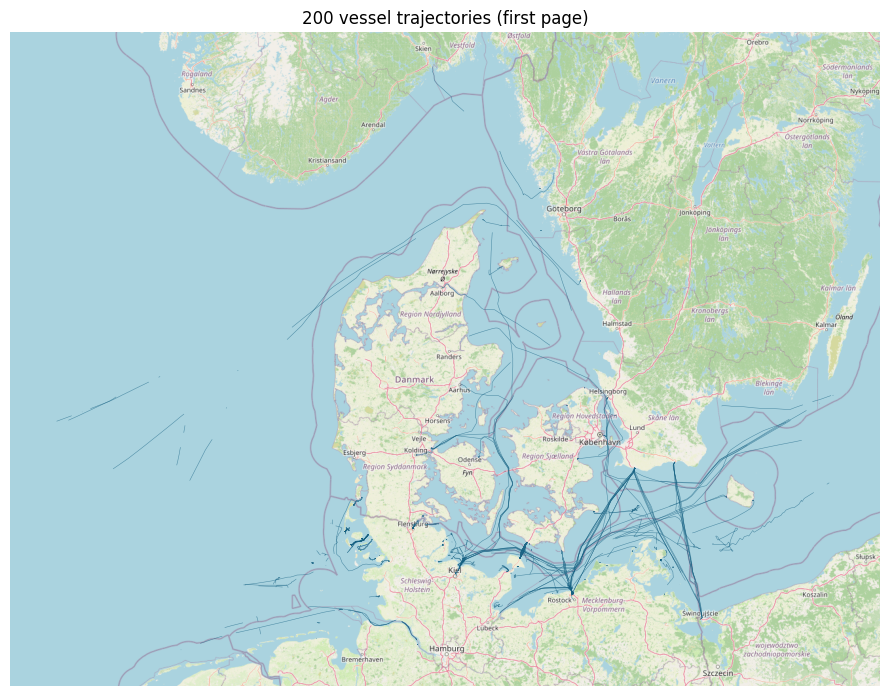

In [4]:
LIMIT = 200
r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items", params={"limit": LIMIT})
r.raise_for_status()
fc = r.json()
features = fc.get("features", [])
print(f"GET items?limit={LIMIT} -> {fc.get('numberReturned')} features")
print("next link:", fc.get("links", [{}])[0].get("href"))

plot_features([(features, "#156082", 0.4, 0.6, None)],
              title=f"{len(features)} vessel trajectories (first page)")

Follow the keyset `next` link to fetch the next page (`?after=<last id>`).

In [5]:
nxt = next((l["href"] for l in fc.get("links", []) if l.get("rel") == "next"), None)
if nxt:
    r = requests.get(HOST + nxt); r.raise_for_status()
    print("followed", nxt, "->", r.json().get("numberReturned"), "more features")
else:
    print("no next link (last page)")

followed /collections/ships/items?after=200&limit=200 -> 200 more features


## A moving feature

`GET /collections/{collectionId}/items/{mFeatureId}` returns one moving feature with
the full standard field set: `crs`, `trs`, `bbox`, `time`, the GeoJSON `geometry`,
the MF-JSON `temporalGeometry`, and a self `link`. `bbox`/`time` come from the inline
STBOX; `crs` is rewritten to the OGC URN.

In [6]:
fid = features[0]["id"]
r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{fid}"); r.raise_for_status()
feat = r.json()
print("feature fields:", sorted(feat.keys()))
print("bbox:", feat["bbox"])
print("time:", feat["time"])
print("crs :", feat["crs"]["properties"]["name"])
print("temporalGeometry.interpolation:", feat["temporalGeometry"]["interpolation"])

feature fields: ['bbox', 'crs', 'geometry', 'id', 'links', 'properties', 'temporalGeometry', 'time', 'trs', 'type']
bbox: [550889.3577712964, 6328752.406299234, 616715.8255644628, 6346258.126580519]
time: ['2026-02-26 13:28:08+01', '2026-02-26 14:41:04+01']
crs : urn:ogc:def:crs:EPSG::25832
temporalGeometry.interpolation: Linear


### Spatial filter (`bbox`)

`GET .../items?bbox=minx,miny,maxx,maxy` keeps the vessels whose trajectory
intersects the envelope, pushed to the MobilityDB GiST index. Coordinates are in the
collection's storage CRS (EPSG:25832). We pick a tight box on a busy shipping lane.

GET items?bbox=... -> 242 vessels intersect the box


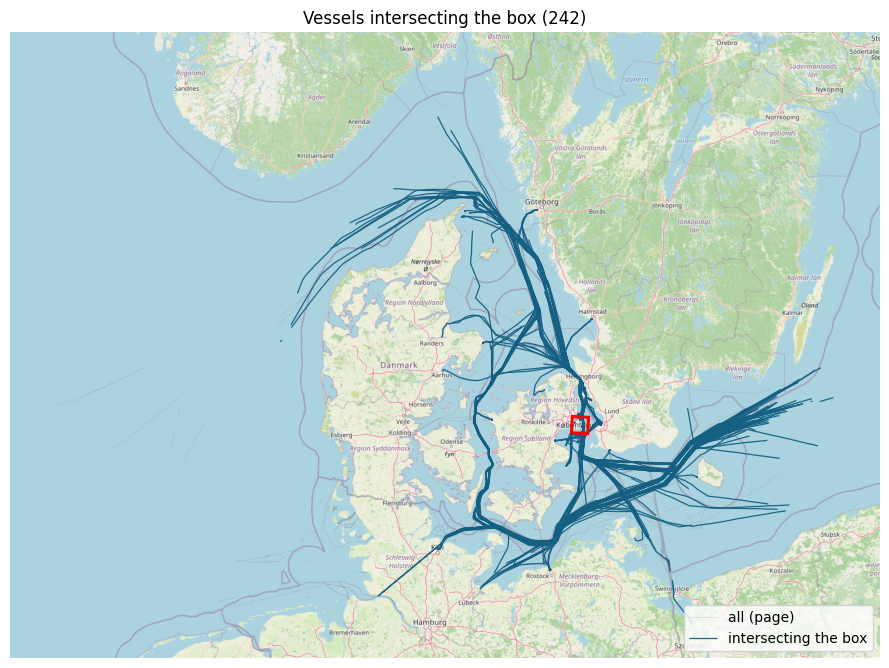

In [7]:
BOX = (720000, 6160000, 738000, 6178000)   # minx,miny,maxx,maxy in EPSG:25832 (metres)
r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items",
                 params={"bbox": ",".join(map(str, BOX)), "limit": 10000})
r.raise_for_status()
features_bbox = r.json().get("features", [])
print(f"GET items?bbox=... -> {len(features_bbox)} vessels intersect the box")

plot_features([(features, "#9aa7b2", 0.4, 0.5, "all (page)"),
               (features_bbox, "#156082", 0.9, 0.95, "intersecting the box")],
              bbox=BOX, title=f"Vessels intersecting the box ({len(features_bbox)})")

### Temporal slice (`subtrajectory`)

`GET .../items?subtrajectory=true&datetime=<start>/<end>` clips each trajectory to
the requested interval with `atTime`. `datetime` follows the
[RFC 3339 interval syntax](https://www.rfc-editor.org/rfc/rfc3339); rows whose values
fall entirely in a temporal gap are dropped.

GET items?subtrajectory=true&datetime=2026-02-26T14:00:00+01/2026-02-26T15:00:00+01 -> 1354 features


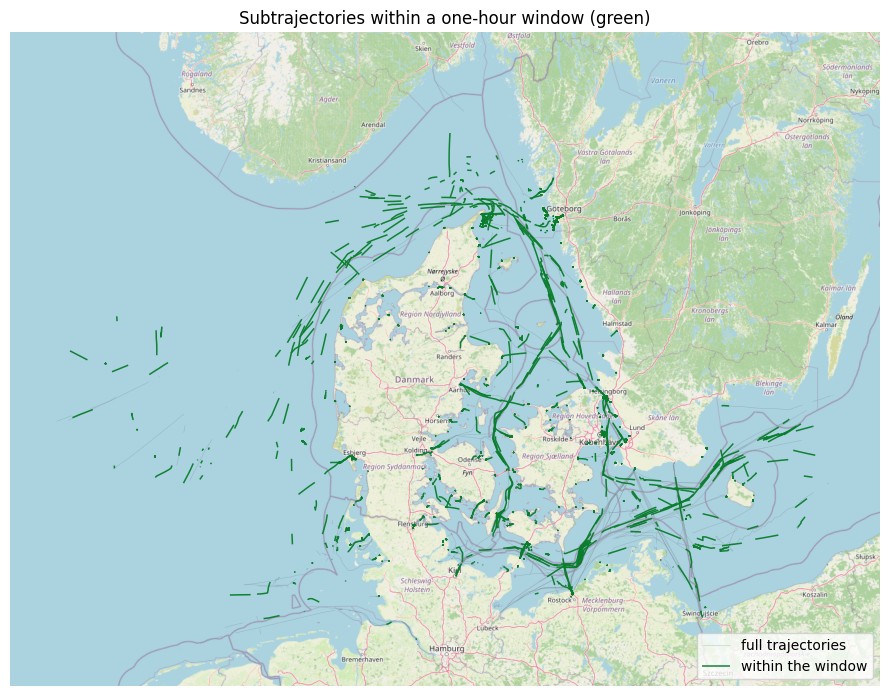

In [8]:
WINDOW = "2026-02-26T13:00:00+00/2026-02-26T14:00:00+00"  # UTC (AIS times are UTC)
r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items",
                 params={"subtrajectory": "true", "datetime": WINDOW, "limit": 10000})
r.raise_for_status()
features_sub = r.json().get("features", [])
print(f"GET items?subtrajectory=true&datetime={WINDOW} -> {len(features_sub)} features")

plot_features([(features, "#8593a0", 0.4, 0.45, "full trajectories"),
               (features_sub, "#0a7d2c", 1.1, 0.95, "within the window")],
              title="Subtrajectories within a one-hour window (green)")

### The temporal-geometry sequence

`GET .../items/{mFeatureId}/tgsequence` returns the moving feature's temporal geometry
as MF-JSON (a `MovingPoint`). `?datetime=<interval>` or `?leaf=<instants>` clip it.

In [9]:
r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{fid}/tgsequence")
r.raise_for_status()
tg = r.json()
seqs = tg["geometrySequence"]
print("type:", tg["type"], "| sequences:", len(seqs),
      "| interpolation:", seqs[0]["interpolation"])

type: MovingPoint | interpolation: Linear | sequences: 2


## Derived measures

`GET .../tgsequence/{tGeometryId}/velocity` returns an OGC `temporalProperty` (a
`TReal`): a `valueSequence` of parallel `datetimes`/`values` with the measure's true
interpolation. `distance` works the same way. **`acceleration` returns `501`** — with
linearly interpolated position the speed is piecewise-constant, so its derivative is
zero within each segment and undefined at the vertices; the tier does not fabricate it.

We fetch velocity for the first few vessels crossing the box and plot the profiles
against a 10-knot (5.14 m/s) reference.

In [10]:
def parse_t(s):                       # "2026-02-26T13:28:08+00" -> datetime (AIS UTC)
    if len(s) >= 3 and s[-3] in "+-": s = s + ":00"
    return datetime.fromisoformat(s)

def velocity_series(prop):
    ts, vs = [], []
    for seq in prop.get("valueSequence", []):
        ts += [parse_t(t) for t in seq["datetimes"]]; vs += seq["values"]
    return ts, vs

ship_ids = [f["id"] for f in features_bbox][:4] or [fid]
profiles = []
for sid in ship_ids:
    r = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{sid}/tgsequence/1/velocity")
    if r.status_code == 200 and r.json().get("valueSequence"):
        profiles.append((sid, r.json()))
print(f"fetched {len(profiles)} velocity profile(s); form = {profiles[0][1]['form']}")

# acceleration is offered at the same path but is not derivable for this motion model
acc = requests.get(f"{HOST}/collections/{COLLECTION_ID}/items/{fid}/tgsequence/1/acceleration")
print("acceleration ->", acc.status_code, acc.json().get("description", "")[:60], "...")

fetched 4 velocity profile(s); form = m/s
acceleration -> 501 acceleration is not derivable: linearly interpolated positio ...


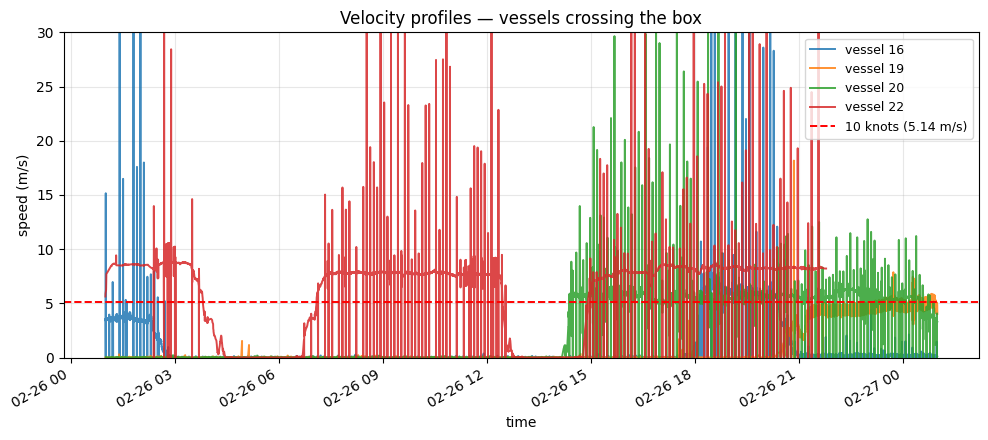

In [11]:
LIMIT_MS = 10 * 0.5144     # 10 knots
fig, ax = plt.subplots(figsize=(10, 4.5))
for sid, prop in profiles:
    ts, vs = velocity_series(prop)
    ax.plot(ts, vs, lw=1.4, alpha=0.85, label=f"vessel {sid}")
ax.axhline(LIMIT_MS, color="red", ls="--", lw=1.4, label=f"10 knots ({LIMIT_MS:.2f} m/s)")
ax.set_ylim(0, 30); ax.set_ylabel(f"speed ({profiles[0][1]['form']})"); ax.set_xlabel("time")
ax.set_title("Velocity profiles — vessels crossing the box"); ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=9); fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## Temporal properties

Temporal properties are user-supplied, time-varying non-spatial attributes of a feature
(fuel, cargo temperature, load…), stored as native MobilityDB temporal values.
`POST .../items/{mFeatureId}/tproperties` adds one or more (a single object or an array);
`GET .../tproperties` lists them and `GET .../tproperties/{name}` returns one as an OGC
`temporalProperty`. `?leaf=<instant>` selects the value(s) at given instants,
`POST .../tproperties/{name}` appends more values (temporally disjoint; overlap → `409`),
and `DELETE .../tproperties/{name}` removes it.

In [ ]:
base = f"{HOST}/collections/{COLLECTION_ID}/items/{fid}/tproperties"

# add a cargo-temperature property (TReal, degrees Celsius) sampled over the afternoon
prop = {"name": "cargo_temp", "type": "TReal", "form": "Cel",
        "description": "Cargo hold temperature",
        "datetimes": ["2026-02-26T12:00:00+00", "2026-02-26T13:00:00+00", "2026-02-26T14:00:00+00"],
        "values": [4.0, 4.6, 5.1], "interpolation": "Linear"}
print("POST   ->", requests.post(base, json=prop).status_code)

# it now appears in the feature's property list
print("list   ->", [p["name"] for p in requests.get(base).json()["temporalProperties"]])

# read it back as an OGC temporalProperty
tp = requests.get(f"{base}/cargo_temp").json()
seq = tp["valueSequence"][0]
print(f"series -> {seq['values']} {tp['form']} (interpolation {seq['interpolation']})")

# leaf selector: the interpolated value at a single instant
leaf = requests.get(f"{base}/cargo_temp", params={"leaf": "2026-02-26T13:30:00+00"}).json()
print("leaf   ->", leaf["valueSequence"][0]["values"])

# append more values (must be temporally disjoint), then remove the property
print("append ->", requests.post(f"{base}/cargo_temp",
      json={"datetimes": ["2026-02-26T15:00:00+00"], "values": [5.4], "interpolation": "Linear"}).status_code)
print("delete ->", requests.delete(f"{base}/cargo_temp").status_code)

### Writes

The tier supports `POST` to create a feature, `PUT` to replace it, `POST .../tgsequence`
to append a temporally-disjoint sub-trajectory (`merge`, which rejects time overlap with
`409`), and `DELETE`. Writes to the derived properties return `501` (they are computed
from the geometry). We create, replace and delete a throwaway feature so the demo data
is unchanged.

In [13]:
DEMO = "900001"
demo_feature = {
    "type": "Feature", "id": DEMO, "properties": {"name": "tutorial demo"},
    "temporalGeometry": {
        "type": "MovingPoint", "interpolation": "Linear",
        "datetimes": ["2026-02-26T10:00:00+00", "2026-02-26T10:00:10+00"],
        "coordinates": [[600000, 6330000], [600100, 6330100]],
    },
}
print("POST  ->", requests.post(f"{HOST}/collections/{COLLECTION_ID}/items", json=demo_feature).status_code)
print("PUT   ->", requests.put(f"{HOST}/collections/{COLLECTION_ID}/items/{DEMO}", json=demo_feature).status_code)
print("DELETE->", requests.delete(f"{HOST}/collections/{COLLECTION_ID}/items/{DEMO}").status_code)

POST  -> 201
PUT   -> 200
DELETE-> 204


### Lakehouse export

`GET .../export` streams the whole collection as **NDJSON** (one `Feature` per line) for
direct ingestion by DuckDB / Spark / pandas; `?format=parquet` emits a columnar file with
the trajectory **WKB plus a bbox/time sidecar** the lake can prune by space and time. The
export is advertised from the collection via the `enclosure` link and streams with bounded
memory. We read just the first NDJSON line here rather than the full feed.

In [14]:
with requests.get(f"{HOST}/collections/{COLLECTION_ID}/export", stream=True) as r:
    r.raise_for_status()
    first = next(r.iter_lines())
line = json.loads(first)
print("first NDJSON feature:", line["id"], "| keys:", sorted(line.keys()))
print("Parquet:  curl '%s/collections/%s/export?format=parquet' -o ships.parquet" % (HOST, COLLECTION_ID))

first NDJSON feature: 1 | keys: ['id', 'properties', 'temporalGeometry', 'type']
Parquet:  curl 'http://localhost:8088/collections/ships/export?format=parquet' -o ships.parquet


## Summary

Every value in this tutorial — a feature, its speed, its derived measures, a
temporal slice — is retrieved in response to a `GET`. The streaming counterpart,
[`tutorial-stream/tutorial.ipynb`](../tutorial-stream/tutorial.ipynb),
registers continuous queries over the same `ships` data and the same `speed`
property and receives the results over Server-Sent Events. The data and the MEOS
computation are identical; only the delivery differs.